## Make an AI pipeline

`segment` -> `condition if it's a car` 

[-> yes] -> `extract license plate using detection model` 

[-> no] ->  `leave it`

In [1]:
print("Making an AI Pipeline")

Making an AI Pipeline


### Sample Text Recognition

In [1]:
import torch
from PIL import Image
from strhub.data.module import SceneTextDataModule

In [3]:

# Load model and image transforms
parseq = torch.hub.load('baudm/parseq', 'parseq', pretrained=True).eval()
img_transform = SceneTextDataModule.get_transform(parseq.hparams.img_size)

# img = Image.open('/path/to/image.png').convert('RGB')
img = Image.open('./testing_images/test_img1.jpg').convert('RGB')

# Preprocess. Model expects a batch of images with shape: (B, C, H, W)
img = img_transform(img).unsqueeze(0)

logits = parseq(img)
logits.shape  # torch.Size([1, 26, 95]), 94 characters + [EOS] symbol

# Greedy decoding
pred = logits.softmax(-1)
label, confidence = parseq.tokenizer.decode(pred)
print('Decoded label = {}'.format(label[0]))

Using cache found in /Users/qbit-glitch/.cache/torch/hub/baudm_parseq_main


Decoded label = RJ14UK1589


In [6]:
def extractTextfromLicensePlate(img_path):
    # Load model and image transforms
    print("Loading PARSeq for License Plate Text Recognition")
    parseq = torch.hub.load('baudm/parseq', 'parseq', pretrained=True).eval()
    img_transform = SceneTextDataModule.get_transform(parseq.hparams.img_size)

    # img = Image.open('/path/to/image.png').convert('RGB')
    img = Image.open(img_path).convert('RGB')

    # Preprocess. Model expects a batch of images with shape: (B, C, H, W)
    img = img_transform(img).unsqueeze(0)

    logits = parseq(img)
    # print(logits.shape)  # torch.Size([1, 26, 95]), 94 characters + [EOS] symbol

    # Greedy decoding
    pred = logits.softmax(-1)
    label, confidence = parseq.tokenizer.decode(pred)
    # print('Decoded label = {}'.format(label[0]))
    return label[0]

img_path = "./testing_images/test_img1.jpg"
print(extractTextfromLicensePlate(img_path))

Loading PARSeq for License Plate Text Recognition


Using cache found in /Users/qbit-glitch/.cache/torch/hub/baudm_parseq_main


RJ14UK1589


### Define the Segmentation and Object Detection model and extract license plate then perform OCR for text recognition

Install Ultralytics

In [7]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 2.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 5.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ultralytics] [ultralytics]

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.203 🚀 Python-3.10.18 torch-2.2.1 CPU (Apple M4 Pro)
Setup complete ✅ (14 CPUs, 48.0 GB RAM, 730.8/926.4 GB disk)


In [10]:
from ultralytics import YOLO

seg_model = YOLO('yolo11m-seg.pt')
plate_model = YOLO('license_plate_detection_model.pt')


In [ ]:
def expand_bbox(box, img_shape, pad_ratio=0.88):
    x1,y1,x2,y2 = box
    w = x2-x1
    h = y2-y1
    padw = w * pad_ratio
    padh = h * pad_ratio

    x1n = max(0, int(x1-padw))
    y1 = max(0, int(y1-padh))
    x2n = min(img_shape[1], int(x2 + padw))
    y2n = min(img_shape[0], int(y2 + padh))

    return x1n, y1, x2n, y2n

In [ ]:
def run_pipeline(image_path, car_class_names=['car','truck','bus']):
    img = cv2.imread(image_path)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    seg_results = seg_model.predict(source=rgb, conf=0.6, verbose=False)

    outputs = []

    for i, clsid in enumerate(seg_results.names[int(clsid)]):
        cls_name = seg_results.names[int(clsid)]
        
        if cls_name != 'car':
            continue
        
        bbox = seg_results.boxes.xyxy[i].cpu().numpy()
        x1,y1,x2,y2 = map(int, bbox)

        x1n, y1n, x2n, y2n = expand_bbox((x1,y1,x2,y2), img.shape, pad_ratio=0.06)
        car_crop = img[y1n:y2n, x1n:x2n]

        # detect license plate inside car crop
        plate_results = plate_model.predict(source=car_crop, conf=0.6, verbose=False)[0]
        plates=[]
        for j, pconf in enumerate(plate_results.boxes.conf.tolist()):
            pb = plate_results.boxes.xyxy[j].cpu().numpy().astype(int)
            px1, py1, px2, py2 = pb

            # crop plate relative to car crop
            plate_img = car_crop[py1:py2, px1:px2]
            if plate_img.size == 0:
                continue

            # OCR (Easy OCR)
            ocr_res = reader.readtext(plate_img, detail=1)

            # normalize OCR output
            if len(ocr_res) > 0:
                best = max(ocr_res, key=lambda r: r[-1])
                plate_text = best[1] if isinstance(best[1], str) else best[0]
                ocr_conf = float(best[-1])
            else:
                plate_text = ""
                ocr_conf = 0.0

            plates.append({
                'plate_bbox_in_car': (int(px1), int(py1), int(px2), int(py2)),
                'plate_image': plate_img,
                'plate_text': plate_text,
                'ocr_conf': ocr_conf,
                'det_conf': float(pconf)
            })
        outputs.append({
            'car_bbox': (x1n, y1n, x2n, y2n),
            'car_conf': conf,
            'plates': plates
        })

    return outputs
    

In [ ]:
image_path = 'test.jpg'
results = run_pipeline(image_path)
for idx, r in enumerate(results):
    print(f"Car {idx}: bbox={r['car_bbox']} conf={r['car_conf']}")
    for p in r['plates']:
        print(f"    Plate det_conf={p['det_conf']:.2f} ocr_conf={p['ocr_conf']:.2f} text='{p['plate_text']}'")
        # optionally save plate image
        Path('out').mkdir(exist_ok=True)
        cv2.imwrite(f"out/car{idx}_plate.jpg", p['plate_image'])

In [69]:
def cropUsingObjectDetectionOnVehicle(img_path, classes):
    model = YOLO("yolo11s.pt")
    results = model.predict(source=img_path, conf=0.6, classes=classes)

    img = cv2.imread(img_path)
    cropped_images = []
    vehicle_boxes = []  # keep track of vehicle coordinates in original image

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            crop = img[y1:y2, x1:x2]
            cropped_images.append(crop)
            vehicle_boxes.append((x1, y1, x2, y2))

    return cropped_images, vehicle_boxes




image 1/1 /Users/qbit-glitch/Desktop/coding-projects/computer_vision_projects/ai_pipeline_license_plate_recognition/testing_images/sample_img2.jpeg: 640x480 1 car, 36.7ms
Speed: 1.5ms preprocess, 36.7ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 480)


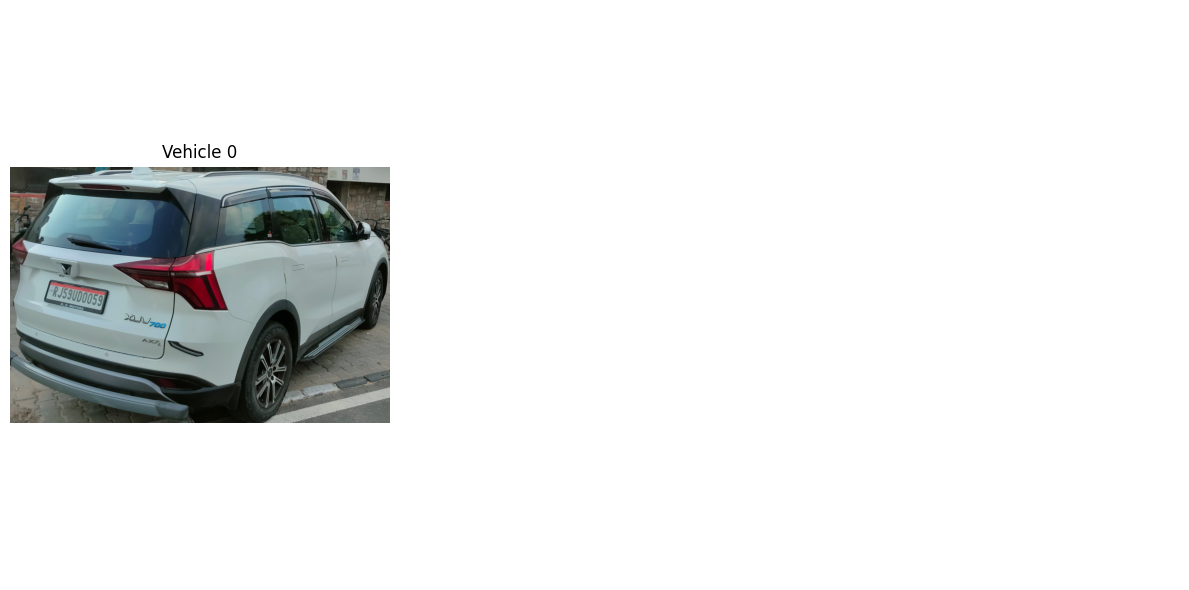

In [70]:
# --- MAIN ---
img_path = "./testing_images/sample_img2.jpeg"

# Detect vehicles
vehicle_crops, vehicle_boxes = cropUsingObjectDetectionOnVehicle(
    img_path, classes=[0, 2, 3, 5, 7]
)

# --- DISPLAY VEHICLES ---
n_vehicles = len(vehicle_crops)
cols = 3
rows = (n_vehicles + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
axes = axes.flatten()

for idx, crop in enumerate(vehicle_crops):
    axes[idx].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f"Vehicle {idx}")
    axes[idx].axis("off")

for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [71]:
def extractBoundingBoxesForLicensePlate(cropped_images, vehicle_boxes):
    model = YOLO("license_plate_detection_model.pt")
    cropped_plates = []
    plate_boxes_global = []

    # Run detection on all vehicle crops
    results = model.predict(source=cropped_images, stream=True)

    for r_idx, r in enumerate(results):  # one result per vehicle crop
        vx1, vy1, _, _ = vehicle_boxes[r_idx]  # offset from original image
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

            # Crop from the vehicle image (local coords)
            crop = r.orig_img[y1:y2, x1:x2]
            cropped_plates.append(crop)

            # Map back to original image coords
            plate_boxes_global.append((x1 + vx1, y1 + vy1, x2 + vx1, y2 + vy1))

    return cropped_plates, plate_boxes_global



0: 448x640 1 negative, 20.0ms
Speed: 1.3ms preprocess, 20.0ms inference, 0.2ms postprocess per image at shape (1, 3, 448, 640)


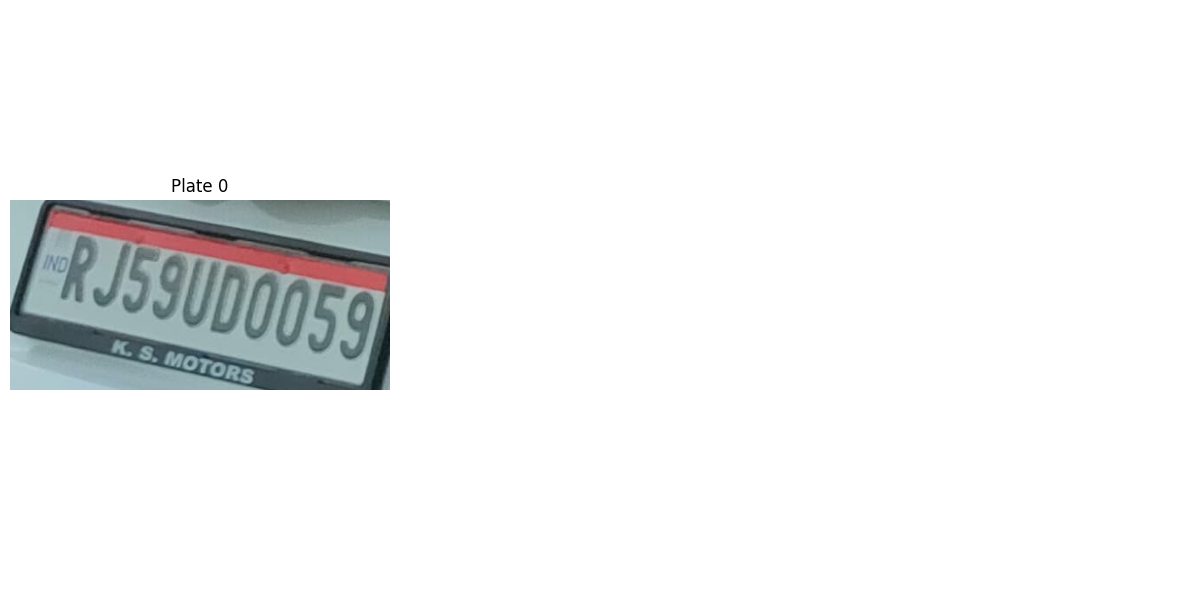

In [72]:

# Detect license plates within vehicle crops
plate_crops, plate_boxes_global = extractBoundingBoxesForLicensePlate(
    vehicle_crops, vehicle_boxes
)

# --- DISPLAY LICENSE PLATES ---
n_plates = len(plate_crops)
cols = 3
rows = (n_plates + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
axes = axes.flatten()

for idx, crop in enumerate(plate_crops):
    axes[idx].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    x1, y1, x2, y2 = plate_boxes_global[idx]
    # axes[idx].set_title(f"Plate {idx}\nGlobal: {x1},{y1},{x2},{y2}")
    axes[idx].set_title(f"Plate {idx}")
    axes[idx].axis("off")

for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch
import cv2
from PIL import Image
from strhub.data.module import SceneTextDataModule

def convertLicensePlateImageToText(plate_crops):

    # Load PARSEQ model
    parseq = torch.hub.load('baudm/parseq', 'parseq', pretrained=True).eval()

    # Get the image transform
    img_transform = SceneTextDataModule.get_transform(parseq.hparams.img_size)

    for idx, crop in enumerate(plate_crops):
        # Convert OpenCV BGR -> RGB
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

        # Convert to PIL image
        pil_img = Image.fromarray(crop_rgb)

        # Apply transforms and add batch dimension
        img_tensor = img_transform(pil_img).unsqueeze(0)  # shape: (1, C, H, W)

        # Forward pass
        with torch.no_grad():
            logits = parseq(img_tensor)

        # Greedy decoding
        pred = logits.softmax(-1)
        label, confidence = parseq.tokenizer.decode(pred)
        
        # Aggregate per-character confidences
        conf_tensor = confidence[0]  # tensor of per-character confidences
        conf_val = conf_tensor.mean().item() if torch.is_tensor(conf_tensor) else conf_tensor

        print(f'Plate {idx}: Decoded label = {label[0]} | Confidence = {conf_val:.2f}')


# Example usage
convertLicensePlateImageToText(plate_crops)


Using cache found in /Users/qbit-glitch/.cache/torch/hub/baudm_parseq_main


Plate 0: Decoded label = RJ59UD0059 | Confidence = 0.98
